In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

In [ ]:
df = pd.read_excel('/content/Sales.xlsx')
df

,Date,SalesRep,Product,Units,Price,Total Sales,City,State,Region,Day
0,2013-01-01,Isabel Cross,Nestle Aero Mint Potz,4,495,1980,Ranchi,Jharkhand,East,Tuesday
1,2013-01-02,Cecilia Manning,Nestle Smarties Pop-Up,2,438,876,Trivandrum,Kerala,South,Wednesday
2,2013-01-02,Isabel Cross,Nestle Maxibon Cookie,1,426,426,Ranchi,Jharkhand,East,Wednesday
3,2013-01-02,Shari Silva,Nestle Maxibon Cookie,2,260,520,Mysore,Karnataka,South,Wednesday
4,2013-01-02,Trevor Jones,Nestle Toffee Crumble,4,285,1140,Pune,Maharashtra,West,Wednesday
...,...,...,...,...,...,...,...,...,...,...
9995,2014-12-31,Cecilia Manning,Nestle Maxibon Cookie,2,430,860,Trivandrum,Kerala,South,Wednesday
9996,2014-12-31,Ben Perez,Nestle Aero Mint Potz,3,173,519,Goa,Goa,West,Wednesday
9997,2014-12-31,Jaime Pearson,Nestle Milky Bar Stick,1,435,435,Jodhpur,Rajasthan,North,Wednesday
9998,2014-12-31,Fernando Rowe,Nestle Smarties Pop-Up,2,486,972,Ahmedabad,Gujarat,West,Wednesday


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         10000 non-null  datetime64[ns]
 1   SalesRep     10000 non-null  object        
 2   Product      10000 non-null  object        
 3   Units        10000 non-null  int64         
 4   Price        10000 non-null  int64         
 5   Total Sales  10000 non-null  int64         
 6   City         10000 non-null  object        
 7   State        10000 non-null  object        
 8   Region       10000 non-null  object        
 9   Day          10000 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 781.4+ KB


In [ ]:
df.describe()

,Date,Units,Price,Total Sales
count,10000,10000.000000,10000.000000,10000.000000
mean,2014-04-14 17:02:49.920000,3.387400,301.278400,1022.662500
min,2013-01-01 00:00:00,1.000000,100.000000,100.000000
25%,2013-11-20 00:00:00,2.000000,201.750000,376.000000
50%,2014-01-20 00:00:00,2.000000,301.000000,636.000000
75%,2014-11-20 00:00:00,3.000000,401.000000,982.000000
max,2014-12-31 00:00:00,25.000000,500.000000,12175.000000
std,NaN,4.318308,115.866159,1453.908181


In [ ]:
df.corrwith(df['Total Sales'], numeric_only = True)

,0
Units,0.896491
Price,0.275973
Total Sales,1.000000


In [ ]:
df.head()

,Date,SalesRep,Product,Units,Price,Total Sales,City,State,Region,Day
0,2013-01-01,Isabel Cross,Nestle Aero Mint Potz,4,495,1980,Ranchi,Jharkhand,East,Tuesday
1,2013-01-02,Cecilia Manning,Nestle Smarties Pop-Up,2,438,876,Trivandrum,Kerala,South,Wednesday
2,2013-01-02,Isabel Cross,Nestle Maxibon Cookie,1,426,426,Ranchi,Jharkhand,East,Wednesday
3,2013-01-02,Shari Silva,Nestle Maxibon Cookie,2,260,520,Mysore,Karnataka,South,Wednesday
4,2013-01-02,Trevor Jones,Nestle Toffee Crumble,4,285,1140,Pune,Maharashtra,West,Wednesday


In [ ]:
print(df['SalesRep'].nunique())
print(df['Product'].nunique())
print(df['City'].nunique())
print(df['State'].nunique())
print(df['Region'].nunique())

72
11
23
15
4


Visualisation

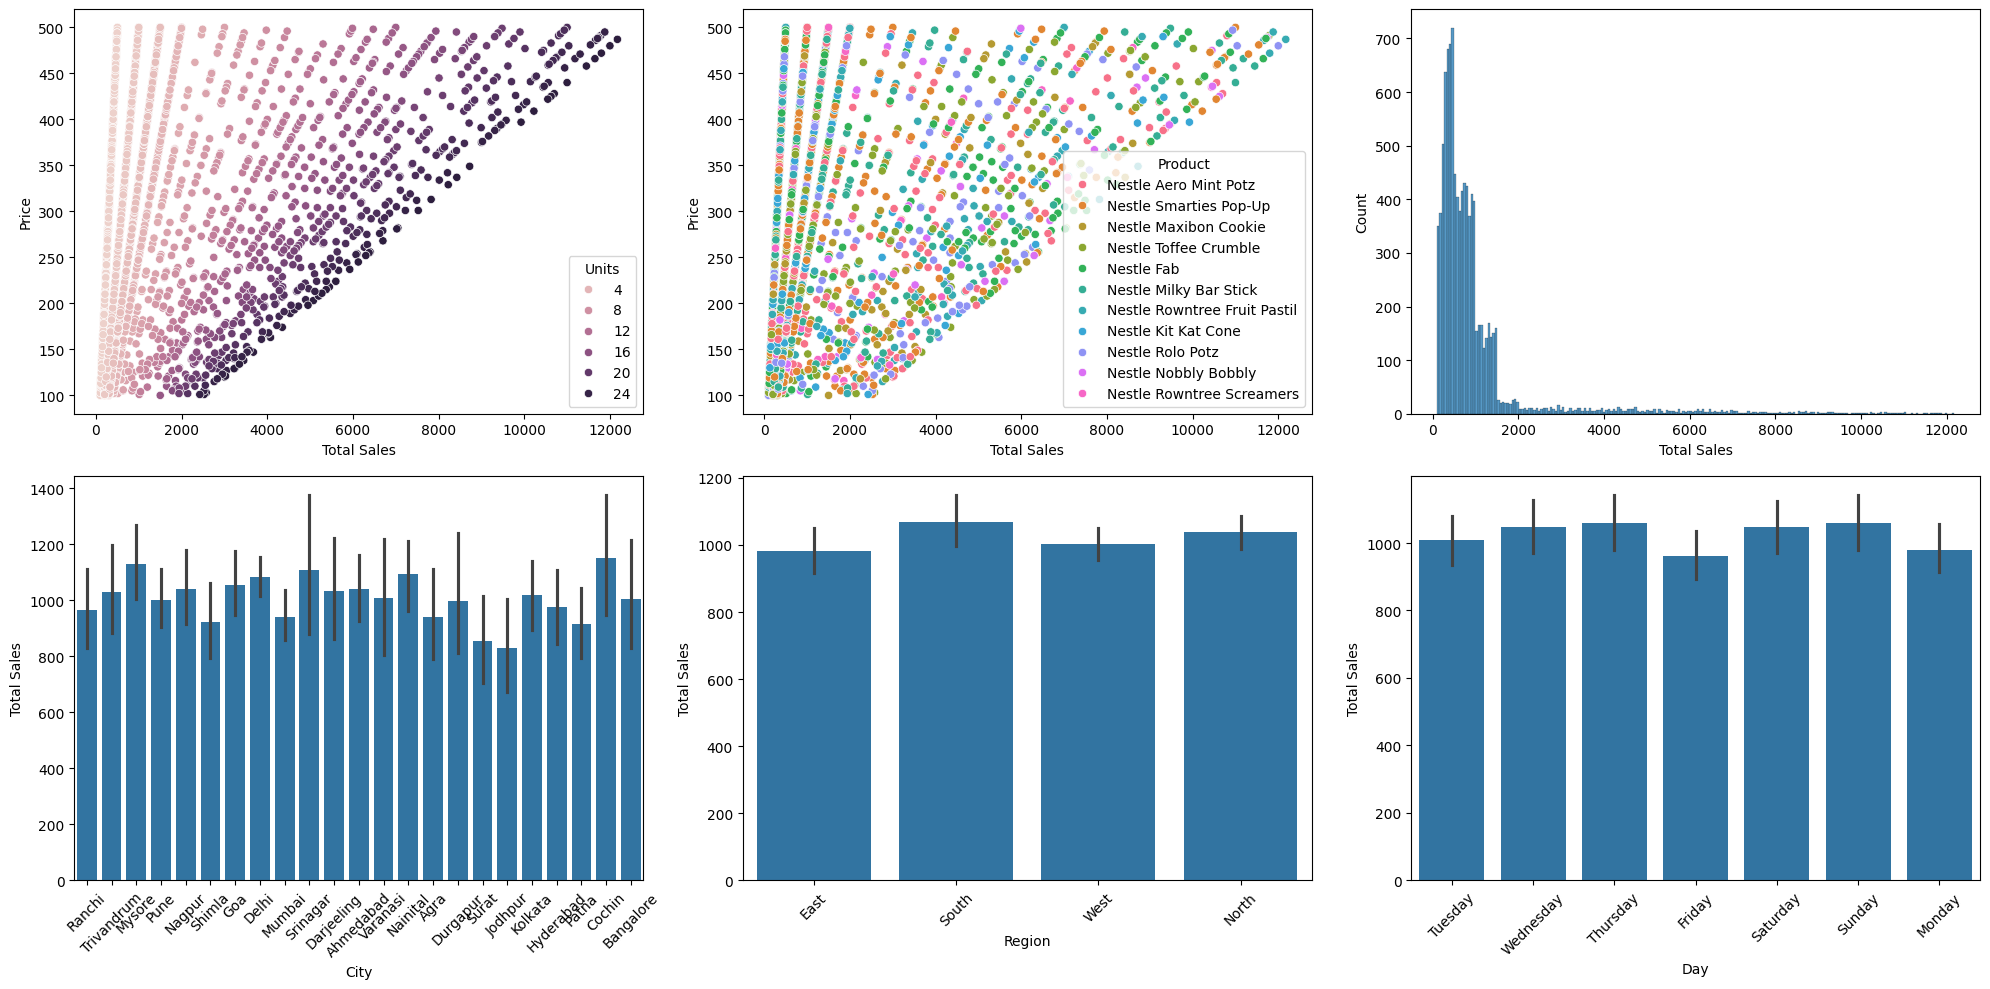

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.scatterplot(data=df, x='Total Sales', y='Price', hue = 'Units', ax=axes[0, 0])
sns.scatterplot(data=df, x='Total Sales', y='Price', hue = 'Product', ax=axes[0, 1])
sns.histplot(data=df, x='Total Sales', ax=axes[0, 2])

sns.barplot(data=df, x='City', y='Total Sales', ax=axes[1, 0])
sns.barplot(data=df, x='Region', y='Total Sales', ax=axes[1, 1])
sns.barplot(data=df, x='Day', y='Total Sales', ax=axes[1, 2])

axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##Train test split

In [ ]:
X = df.drop('Total Sales', axis = 1)
y = df['Total Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
numerical_cols = X.select_dtypes(include=['int', 'float']).columns
categorical_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [ ]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

##Linear Regression

In [ ]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

y_pred = linear.predict(X_test_scaled)

#RMSE and MAE
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}\nMAE: {mae}")

RMSE: 477.89181165822197
MAE: 227.59081519291928


##Logistic regression

In [ ]:
logistic = LogisticRegression()
logistic.fit(X_train_scaled, y_train)

y_pred = logistic.predict(X_test_scaled)

#RMSE and MAE
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}\nMAE: {mae}")

RMSE: 795.2187085953146
MAE: 389.7725


##Decision Tree


In [ ]:
tree = DecisionTreeRegressor(random_state = 42)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best parameters: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV RMSE: 83.73501062606675


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

#RMSE and MAE
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}\nMAE: {mae}")

RMSE: 65.34638065935847
MAE: 14.752166666666668


##Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators = 20, random_state = 42)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

#RMSE and MAE
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}\nMAE: {mae}")

RMSE: 42.8559341281928
MAE: 10.552850000000003


In [ ]:
from scipy.stats import randint
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_scaled, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("Best CV RMSE:")
print(-random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV RMSE:
576.1632116332422


In [ ]:
rf = RandomForestRegressor(n_estimators = 150, random_state = 42, min_samples_split = 2, min_samples_leaf = 2)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

#RMSE and MAE
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}\nMAE: {mae}")

RMSE: 34.489514248147664
MAE: 8.017387698551449


##XGBoost

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state = 42)
xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)

#RMSE and MAE
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}\nMAE: {mae}")

RMSE: 37.73011016845703
MAE: 12.781834602355957


Conclusion: best_model >> random forest after hyperparameters tuning > RMSE: 34 MAE: 8